# Análise Exploratória de Dados - Acidentes Rodoviários (PRF 2023 - 2024)
**Autor:** Felipe Galindo

**Objetivo:** Identificar padrões e fatores de risco nos acidentes rodoviários registrados pela Polícia Rodoviária Federal (PRF) nos anos de 2023 e 2024, fornecendo insights que possam apoiar ações preventivas e operacionais.

In [18]:
# Importando as bibliotecas
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from datetime import datetime

In [2]:
# Fazendo a leitura dos dados
caminho_prf_consolidados = os.path.join(
    '..', 'data', 'processed', 'dados_prf_consolidados.csv'
)

df_prf = pd.read_csv(caminho_prf_consolidados, sep=';', encoding='latin1')

C:\Users\felip\AppData\Local\Temp\ipykernel_13112\646410446.py:6: DtypeWarning: Columns (25,26) have mixed types. Specify dtype option on import or set low_memory=False.
  df_prf = pd.read_csv(caminho_prf_consolidados, sep=';', encoding='latin1')


In [3]:
# Função para verificar todas as colunas e linhas
pd.set_option('display.max_columns', None, 'display.max_rows', None)

Carregando os Meta Dados

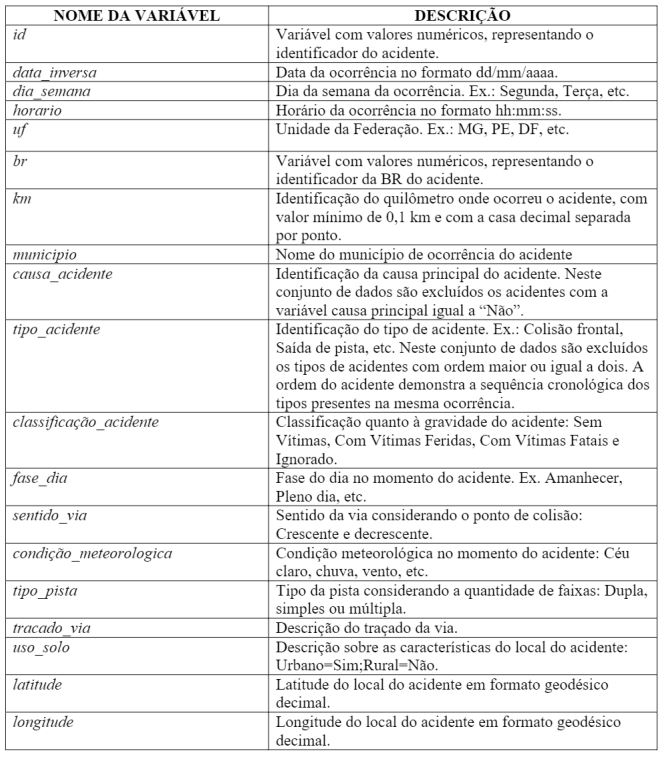

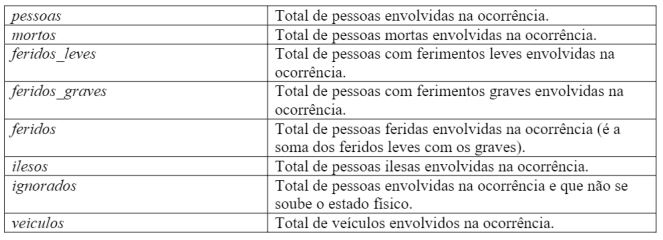

## 2. Momento de Exploração dos Dados

In [4]:
df_prf.head()

,id,data_inversa,dia_semana,horario,uf,br,km,municipio,causa_acidente,tipo_acidente,classificacao_acidente,fase_dia,sentido_via,condicao_metereologica,tipo_pista,tracado_via,uso_solo,pessoas,mortos,feridos_leves,feridos_graves,ilesos,ignorados,feridos,veiculos,latitude,longitude,regional,delegacia,uop,ano
0,496519.0,2023-01-01,domingo,02:00:00,ES,101,114,SOORETAMA,Ausência de reação do condutor,Saída de leito carroçável,Com Vítimas Feridas,Plena Noite,Crescente,Céu Claro,Simples,Reta,Não,1,0,1,0,0,0,1,1,"-19,09484877","-40,05095848",SPRF-ES,DEL04-ES,UOP01-DEL04-ES,2023
1,496543.0,2023-01-01,domingo,03:40:00,SP,116,"113,1",TAUBATE,Entrada inopinada do pedestre,Atropelamento de Pedestre,Com Vítimas Fatais,Plena Noite,Decrescente,Céu Claro,Dupla,Reta,Sim,5,1,0,0,0,4,0,2,"-23,0445658","-45,58259814",SPRF-SP,DEL02-SP,UOP02-DEL02-SP,2023
2,496590.0,2023-01-01,domingo,01:40:00,MT,163,1112,GUARANTA DO NORTE,Reação tardia ou ineficiente do condutor,Tombamento,NaN,Plena Noite,Crescente,Ignorado,Simples,Curva;Declive,Não,2,0,0,1,0,2,1,3,"-9,70020602","-54,87588757",SPRF-MT,DEL06-MT,UOP03-DEL06-MT,2023
3,496610.0,2023-01-01,domingo,10:40:00,PR,376,"314,8",ORTIGUEIRA,Velocidade Incompatível,Tombamento,Sem Vítimas,Pleno dia,Crescente,Sol,Dupla,Curva,Não,2,0,0,0,1,2,0,3,"-23,985512","-51,083555",SPRF-PR,DEL07-PR,UOP02-DEL07-PR,2023
4,496659.0,2023-01-01,domingo,14:55:00,MG,116,"569,4",MANHUACU,Acumulo de água sobre o pavimento,Colisão frontal,Com Vítimas Feridas,Pleno dia,Decrescente,Chuva,Simples,Declive;Curva,Não,4,0,0,2,1,1,2,3,"-20,10007457","-42,17884091",SPRF-MG,DEL06-MG,UOP03-DEL06-MG,2023


In [5]:
df_prf.shape
# 140922 linhas e 31 colunas

(140922, 31)

In [6]:
# Verificando se existe linhas duplicadas
df_prf.duplicated().sum()

np.int64(0)

In [7]:
df_prf.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 140922 entries, 0 to 140921
Data columns (total 31 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   id                      140922 non-null  float64
 1   data_inversa            140922 non-null  object 
 2   dia_semana              140922 non-null  object 
 3   horario                 140922 non-null  object 
 4   uf                      140922 non-null  object 
 5   br                      140922 non-null  int64  
 6   km                      140922 non-null  object 
 7   municipio               140922 non-null  object 
 8   causa_acidente          140922 non-null  object 
 9   tipo_acidente           140922 non-null  object 
 10  classificacao_acidente  140920 non-null  object 
 11  fase_dia                140922 non-null  object 
 12  sentido_via             140922 non-null  object 
 13  condicao_metereologica  140922 non-null  object 
 14  tipo_pista          

In [8]:
df_prf.describe()

,id,br,pessoas,mortos,feridos_leves,feridos_graves,ilesos,ignorados,feridos,veiculos,ano
count,140922.000000,140922.000000,140922.000000,140922.000000,140922.000000,140922.000000,140922.000000,140922.000000,140922.000000,140922.000000,140922.000000
mean,575560.327813,209.426520,2.605789,0.083642,0.877698,0.278892,1.055492,0.398440,1.156590,1.991584,2023.519124
std,45075.436594,129.243035,2.260555,0.353453,1.115905,0.626801,1.777051,0.857437,1.241434,1.149673,0.499636
min,496506.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2023.000000
25%,536625.250000,101.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,2023.000000
50%,575610.500000,158.000000,2.000000,0.000000,1.000000,0.000000,1.000000,0.000000,1.000000,2.000000,2024.000000
75%,614739.750000,324.000000,3.000000,0.000000,1.000000,0.000000,1.000000,1.000000,1.000000,2.000000,2024.000000
max,661607.000000,498.000000,95.000000,37.000000,83.000000,35.000000,78.000000,88.000000,84.000000,131.000000,2024.000000


Insights iniciais:

- Cerca de 8 mortes a cada 100 acidentes (taxa de fatalidade inicial de 8%)
- Geralmente há mais de uma pessoa ilesa por acorrência.
- Confirma que a maioria dos acidentes envolve 1-2 veículos.
- feridos_graves relativamente baixo, reforça a maior quantidade em feridos_leves.

Os dados sugerem que a maior parte dos acidentes é de baixa gravidade e envolve poucos veículos, mas há casos extremos (até 37 mortos e 131 veículos) que podem ser outliers a verificar.

In [9]:
# ============================================================
# Função para análisar os Metadados do Data Set
# ============================================================

def generate_metadata(dataframe: pd.DataFrame):
    """
    Gera um DataFrame de metadados de um DataFrame fornecido.
    return: DataFrame contendo os metadados
    """

    # Coleta de metadados básicos
    metadata = pd.DataFrame({
        'nome_variavel':dataframe.columns,
        'tipo':dataframe.dtypes,
        'qnt_nulos':dataframe.isnull().sum(),
        'percent_nulos': round((dataframe.isnull().sum() / len(dataframe)) * 100, 2),
        'cardinalidade':dataframe.nunique()
    })

    return metadata.sort_values('tipo').reset_index(drop=True)

metadata_df = generate_metadata(df_prf)
metadata_df

,nome_variavel,tipo,qnt_nulos,percent_nulos,cardinalidade
0,ano,int64,0,0.00,2
1,veiculos,int64,0,0.00,24
2,feridos,int64,0,0.00,49
3,ignorados,int64,0,0.00,21
4,ilesos,int64,0,0.00,62
5,br,int64,0,0.00,122
6,feridos_graves,int64,0,0.00,23
7,feridos_leves,int64,0,0.00,44
8,mortos,int64,0,0.00,13
9,pessoas,int64,0,0.00,69


In [10]:
# Salvando os metadados
caminho_salvar = os.path.join(
   'C:\\Users\\felip\\PythonProjects\\Projetos_Pod_Academy\\Projeto_PRF\\Projeto_PRF_23_24\\data\\metadata',
   'meta_data.csv'
)

metadata_df.to_csv(caminho_salvar, encoding='latin1')

## 3. Limpeza e Transformação dos Dados

### 3.1 Tratamento de valores ausentes em `classificacao_acidente`

Durante o processo de limpeza, foram identificados **2 registros** com valor ausente (`NaN`) na variável `classificacao_acidente`.
  
Como ambos apresentavam `mortos = 0`, esses casos foram recategorizados como **"Sem Vítimas"**, mantendo a coerência lógica entre as variáveis e a definição da classificação do acidente.

In [8]:
# Visualizando a cardinalidade de 'classificacao_acidente'
df_prf['classificacao_acidente'].unique()

array(['Com Vítimas Feridas', 'Com Vítimas Fatais', nan, 'Sem Vítimas'],
      dtype=object)

In [9]:
# Visualizar os registros que estão NoN em 'classificacao_acidente':
display(df_prf[df_prf['classificacao_acidente'].isna()])

,id,data_inversa,dia_semana,horario,uf,br,km,municipio,causa_acidente,tipo_acidente,classificacao_acidente,fase_dia,sentido_via,condicao_metereologica,tipo_pista,tracado_via,uso_solo,pessoas,mortos,feridos_leves,feridos_graves,ilesos,ignorados,feridos,veiculos,latitude,longitude,regional,delegacia,uop,ano
2,496590.0,2023-01-01,domingo,01:40:00,MT,163,1112,GUARANTA DO NORTE,Reação tardia ou ineficiente do condutor,Tombamento,NaN,Plena Noite,Crescente,Ignorado,Simples,Curva;Declive,Não,2,0,0,1,0,2,1,3,"-9,70020602","-54,87588757",SPRF-MT,DEL06-MT,UOP03-DEL06-MT,2023
67766,571789.0,2024-01-01,segunda-feira,03:56:00,ES,101,38,CONCEICAO DA BARRA,Ultrapassagem Indevida,Colisão lateral sentido oposto,NaN,Plena Noite,Crescente,Céu Claro,Simples,Reta,Não,3,0,0,1,1,1,1,3,-18.48261,-39.92379,SPRF-ES,DEL04-ES,UOP02-DEL04-ES,2024


In [10]:
# Cardinalidade de classificacao_acidente x mortos
df_prf[['classificacao_acidente', 'mortos']].drop_duplicates()

,classificacao_acidente,mortos
0,Com Vítimas Feridas,0
1,Com Vítimas Fatais,1
2,NaN,0
3,Sem Vítimas,0
162,Com Vítimas Fatais,2
218,Com Vítimas Fatais,4
515,Com Vítimas Fatais,5
518,Com Vítimas Fatais,3
2549,Com Vítimas Fatais,7
15578,Com Vítimas Fatais,6


In [11]:
# Fazendo a alteração dos dois valores NoN para 'Sem Vítimas'
df_prf.loc[(df_prf['classificacao_acidente'].isna()) & (df_prf['mortos'] == 0), 'classificacao_acidente'] = 'Sem Vítimas'

In [12]:
# Conferindo alteração
df_prf[df_prf['classificacao_acidente'].isna()]

,id,data_inversa,dia_semana,horario,uf,br,km,municipio,causa_acidente,tipo_acidente,classificacao_acidente,fase_dia,sentido_via,condicao_metereologica,tipo_pista,tracado_via,uso_solo,pessoas,mortos,feridos_leves,feridos_graves,ilesos,ignorados,feridos,veiculos,latitude,longitude,regional,delegacia,uop,ano


Resultado: Todos os registros de `classificacao_acidente` foram corrigidos sem perda de informação.

### 3.2 Transformação dos tipos de dados das colunas

In [11]:
# Transformando as colunas de horário e data_inversa em datetime
df_prf['horario'] = pd.to_datetime(df_prf['horario'], format='%H:%M:%S', errors='coerce')
df_prf['data_inversa'] = pd.to_datetime(df_prf['data_inversa'], format='%Y-%m-%d', errors='coerce')

# Verificando a transformação
df_prf[['horario', 'data_inversa']].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 140922 entries, 0 to 140921
Data columns (total 2 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   horario       140922 non-null  datetime64[ns]
 1   data_inversa  140922 non-null  datetime64[ns]
dtypes: datetime64[ns](2)
memory usage: 2.2 MB


In [12]:
df_prf['latitude'] = df_prf['latitude'].str.replace(',', '.')
df_prf['longitude'] = df_prf['longitude'].str.replace(',', '.')

df_prf['latitude'] = df_prf['latitude'].replace('NaN', np.nan).astype(float)
df_prf['longitude'] = df_prf['longitude'].replace('NaN', np.nan).astype(float)

In [13]:
# Verificando a transformação
df_prf[['latitude', 'longitude']].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 140922 entries, 0 to 140921
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   latitude   98304 non-null  float64
 1   longitude  98304 non-null  float64
dtypes: float64(2)
memory usage: 2.2 MB


In [14]:
# Verificando quantos valores nulos realmente existem nas colunas.
print(df_prf[['latitude', 'longitude']].isna().sum())

# Vamos verificar quantos registros estão sem coordenadas nas duas variáveis
sem_coordenadas = df_prf[df_prf['latitude'].isna() & df_prf['longitude'].isna()]
print(f'Registros sem coordenadas: {sem_coordenadas.shape[0]} de {df_prf.shape[0]}')

latitude     42618
longitude    42618
dtype: int64
Registros sem coordenadas: 42618 de 140922


Durante a etapa de preparação dos dados, foram realizadas transformações de tipo em variáveis que continham informações temporais e geográficas, a fim de padronizar o formato e permitir análises consistentes:

- Coluna data_inversa: convertida de object para o tipo datetime, possibilitando operações temporais como extração de ano, mês, dia da semana e comparações entre períodos.
- Coluna horario: convertida de object para o tipo datetime.time, permitindo análises relacionadas à distribuição dos acidentes ao longo do dia (manhã, tarde, noite e madrugada).
- Colunas latitude e longitude: inicialmente armazenadas como object (string), foram padronizadas substituindo vírgulas por pontos decimais e convertidas para o tipo float. Essa 
transformação possibilita o uso futuro em análises geográficas ou visualizações em mapas.

🔹 Observação:
O resultado dos registros sem coordenadas — 42.618 de 140.922 — reforça que os dados com latitude nula também apresentam longitude nula, e vice-versa. Isso indica que a ausência dessas informações é consistente entre as duas variáveis, sugerindo que os pontos sem coordenadas não possuem localização geográfica registrada no dataset original.

### 3.3 - Criação de Variáveis Derivadas

Criação da Variável de 'Mês' para Análises Futuras

In [15]:
meses = {1: 'Janeiro', 2: 'Fevereiro', 3: 'Março', 4: 'Abril', 5: 'Maio', 6: 'Junho',
         7: 'Julho', 8: 'Agosto', 9: 'Setembro', 10: 'Outubro', 11: 'Novembro', 12: 'Dezembro'}

df_prf['nome_mes'] = df_prf['data_inversa'].dt.month.map(meses)

# Conferindo a criação da variável
df_prf['nome_mes'].unique()

array(['Janeiro', 'Fevereiro', 'Março', 'Abril', 'Maio', 'Junho', 'Julho',
       'Agosto', 'Setembro', 'Outubro', 'Novembro', 'Dezembro'],
      dtype=object)

Criação da Variável de 'Turno' para Análises Futuras

In [19]:
def definir_turno(hora: datetime) -> str:
    if (hora >= 6) & (hora < 12):
        return 'Manhã'
    if (hora >= 12) & (hora < 18):
        return 'Tarde'
    if (hora >= 18) & (hora < 24):
        return 'Noite'
    else:
        return 'Madrugada'

df_prf['turno'] = df_prf['horario'].dt.hour.apply(definir_turno)

# Conferindo a criação da variável
df_prf[['horario', 'turno']].head(10)

,horario,turno
0,1900-01-01 02:00:00,Madrugada
1,1900-01-01 03:40:00,Madrugada
2,1900-01-01 01:40:00,Madrugada
3,1900-01-01 10:40:00,Manhã
4,1900-01-01 14:55:00,Tarde
5,1900-01-01 15:45:00,Tarde
6,1900-01-01 18:10:00,Noite
7,1900-01-01 20:00:00,Noite
8,1900-01-01 21:54:00,Noite
9,1900-01-01 21:50:00,Noite


## 4. Análise Descritiva

In [ ]:
municipios_top10 = pd.DataFrame(
    df_prf
    .groupby(['municipio', 'uf'])
    .size()
    .sort_values(ascending=False)
    .head(10)
    .reset_index(name='quantidade')
)
municipios_top10

,municipio,uf,quantidade
0,BRASILIA,DF,2033
1,GUARULHOS,SP,1743
2,DUQUE DE CAXIAS,RJ,1496
3,SAO JOSE,SC,1471
4,BETIM,MG,1322
5,CURITIBA,PR,1272
6,RECIFE,PE,1270
7,PALHOCA,SC,1177
8,SERRA,ES,1048
9,SAO JOSE DOS PINHAIS,PR,948


In [76]:
acidentes_por_dia = pd.DataFrame(
    df_prf
    .groupby('dia_semana')
    .size()
    .sort_values(ascending=False)
    .head(10)
    .reset_index(name='quantidade')
)

acidentes_por_dia

,dia_semana,quantidade
0,domingo,23006
1,sábado,22744
2,sexta-feira,21685
3,segunda-feira,19459
4,quinta-feira,18494
5,quarta-feira,17881
6,terça-feira,17653


In [75]:
df_prf.describe(include='all')

,id,data_inversa,dia_semana,horario,uf,br,km,municipio,causa_acidente,tipo_acidente,classificacao_acidente,fase_dia,sentido_via,condicao_metereologica,tipo_pista,tracado_via,uso_solo,pessoas,mortos,feridos_leves,feridos_graves,ilesos,ignorados,feridos,veiculos,latitude,longitude,regional,delegacia,uop,ano,turno
count,140922.000000,140922,140922,140922,140922,140922.000000,140922,140922,140922,140922,140920,140922,140922,140922,140922,140922,140922,140922.000000,140922.000000,140922.000000,140922.000000,140922.000000,140922.000000,140922.000000,140922.000000,140922,140922,140902,140854,140764,140922.000000,140922
unique,NaN,NaN,7,NaN,27,NaN,8715,1925,75,17,3,4,3,10,3,875,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,79995,79974,28,152,400,NaN,4
top,NaN,NaN,domingo,NaN,MG,NaN,1,BRASILIA,Reação tardia ou ineficiente do condutor,Colisão traseira,Com Vítimas Feridas,Pleno dia,Crescente,Céu Claro,Simples,Reta,Não,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"-23,52251783","-46,5855702",SPRF-MG,DEL01-PR,UOP01-DEL01-SC,NaN,Tarde
freq,NaN,NaN,23006,NaN,18303,NaN,697,2033,20775,26869,108098,77607,75991,89420,68648,78280,81026,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,80,80,18256,5026,2336,NaN,43065
mean,575560.327813,2024-01-11 23:47:00.743389952,NaN,1900-01-01 13:18:46.286456064,NaN,209.426520,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.605789,0.083642,0.877698,0.278892,1.055492,0.398440,1.156590,1.991584,NaN,NaN,NaN,NaN,NaN,2023.519124,NaN
min,496506.000000,2023-01-01 00:00:00,NaN,1900-01-01 00:00:00,NaN,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,NaN,NaN,NaN,NaN,NaN,2023.000000,NaN
25%,536625.250000,2023-07-14 00:00:00,NaN,1900-01-01 08:14:00,NaN,101.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,NaN,NaN,NaN,NaN,NaN,2023.000000,NaN
50%,575610.500000,2024-01-14 00:00:00,NaN,1900-01-01 14:00:00,NaN,158.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.000000,0.000000,1.000000,0.000000,1.000000,0.000000,1.000000,2.000000,NaN,NaN,NaN,NaN,NaN,2024.000000,NaN
75%,614739.750000,2024-07-13 00:00:00,NaN,1900-01-01 18:25:00,NaN,324.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.000000,0.000000,1.000000,0.000000,1.000000,1.000000,1.000000,2.000000,NaN,NaN,NaN,NaN,NaN,2024.000000,NaN
max,661607.000000,2024-12-31 00:00:00,NaN,1900-01-01 23:59:00,NaN,498.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,95.000000,37.000000,83.000000,35.000000,78.000000,88.000000,84.000000,131.000000,NaN,NaN,NaN,NaN,NaN,2024.000000,NaN


- Quantidade de Observações: Existem 140.922 registros no conjunto de dados. Isso indica uma quantidade considerável de incidentes registrados.

- Valores Nulos: Algumas colunas, como regional, uop e delegacia, têm menos observações do que o total de registros, indicando a presença de valores nulos.

- Incidentes por Dia: Os dias com mais incidentes é o "domingo" (23.006 registros), com o "sábado" (22.744) bem próximo, o que pode indicar que os finais de semana têm uma frequência mais alta de incidentes ou que as pessoas viajam mais nesses dias.

- Localização dos Incidentes: A maioria dos incidentes ocorre em Minas Gerais (MG), com 18.303 registros.

- Causa mais Comum: A causa mais frequente de incidentes é a "Reação tardia ou ineficiente do condutor", ocorrendo 20.775 vezes.

- Tipo de Acidente mais Comum: A "Colisão traseira" é o tipo mais comum de acidente, ocorrendo 26.869 vezes.

- Quantidade de Veículos Envolvidos: Em média, cada incidente envolve aproximadamente 1,99 veículos.

- Vítimas: A média de feridos por incidente é de 1,15, com um máximo de 84 feridos em um único incidente. Além disso, a média de feridos graves por incidente é de 0,28.

- Distribuição de Incidentes ao Longo do Ano: O dia com o maior número de incidentes registrados é "2024-12-21", com 319 incidentes. Isso demonstra o grande fluxo de veículos na véspera do Natal

- Diversidade de Causas e Tipos: Há 75 causas diferentes de acidentes e 17 tipos diferentes de acidentes listados no conjunto de dados.

- Apesar de "Minas Gerais" ser o Estado com maior quantidade de acidentes. Somente o municipio de "Betim" aparece no top 10 cidades com maior quantidade de acidentes no Brasil. Sendo assim, os acidentes de "Minas Gerais" indicam ter uma grande distribuição pelo Estado.

## 4.1 Visão de Distribuição dos Dados

### Análisando todas as colunas numéricas por BoxPlots

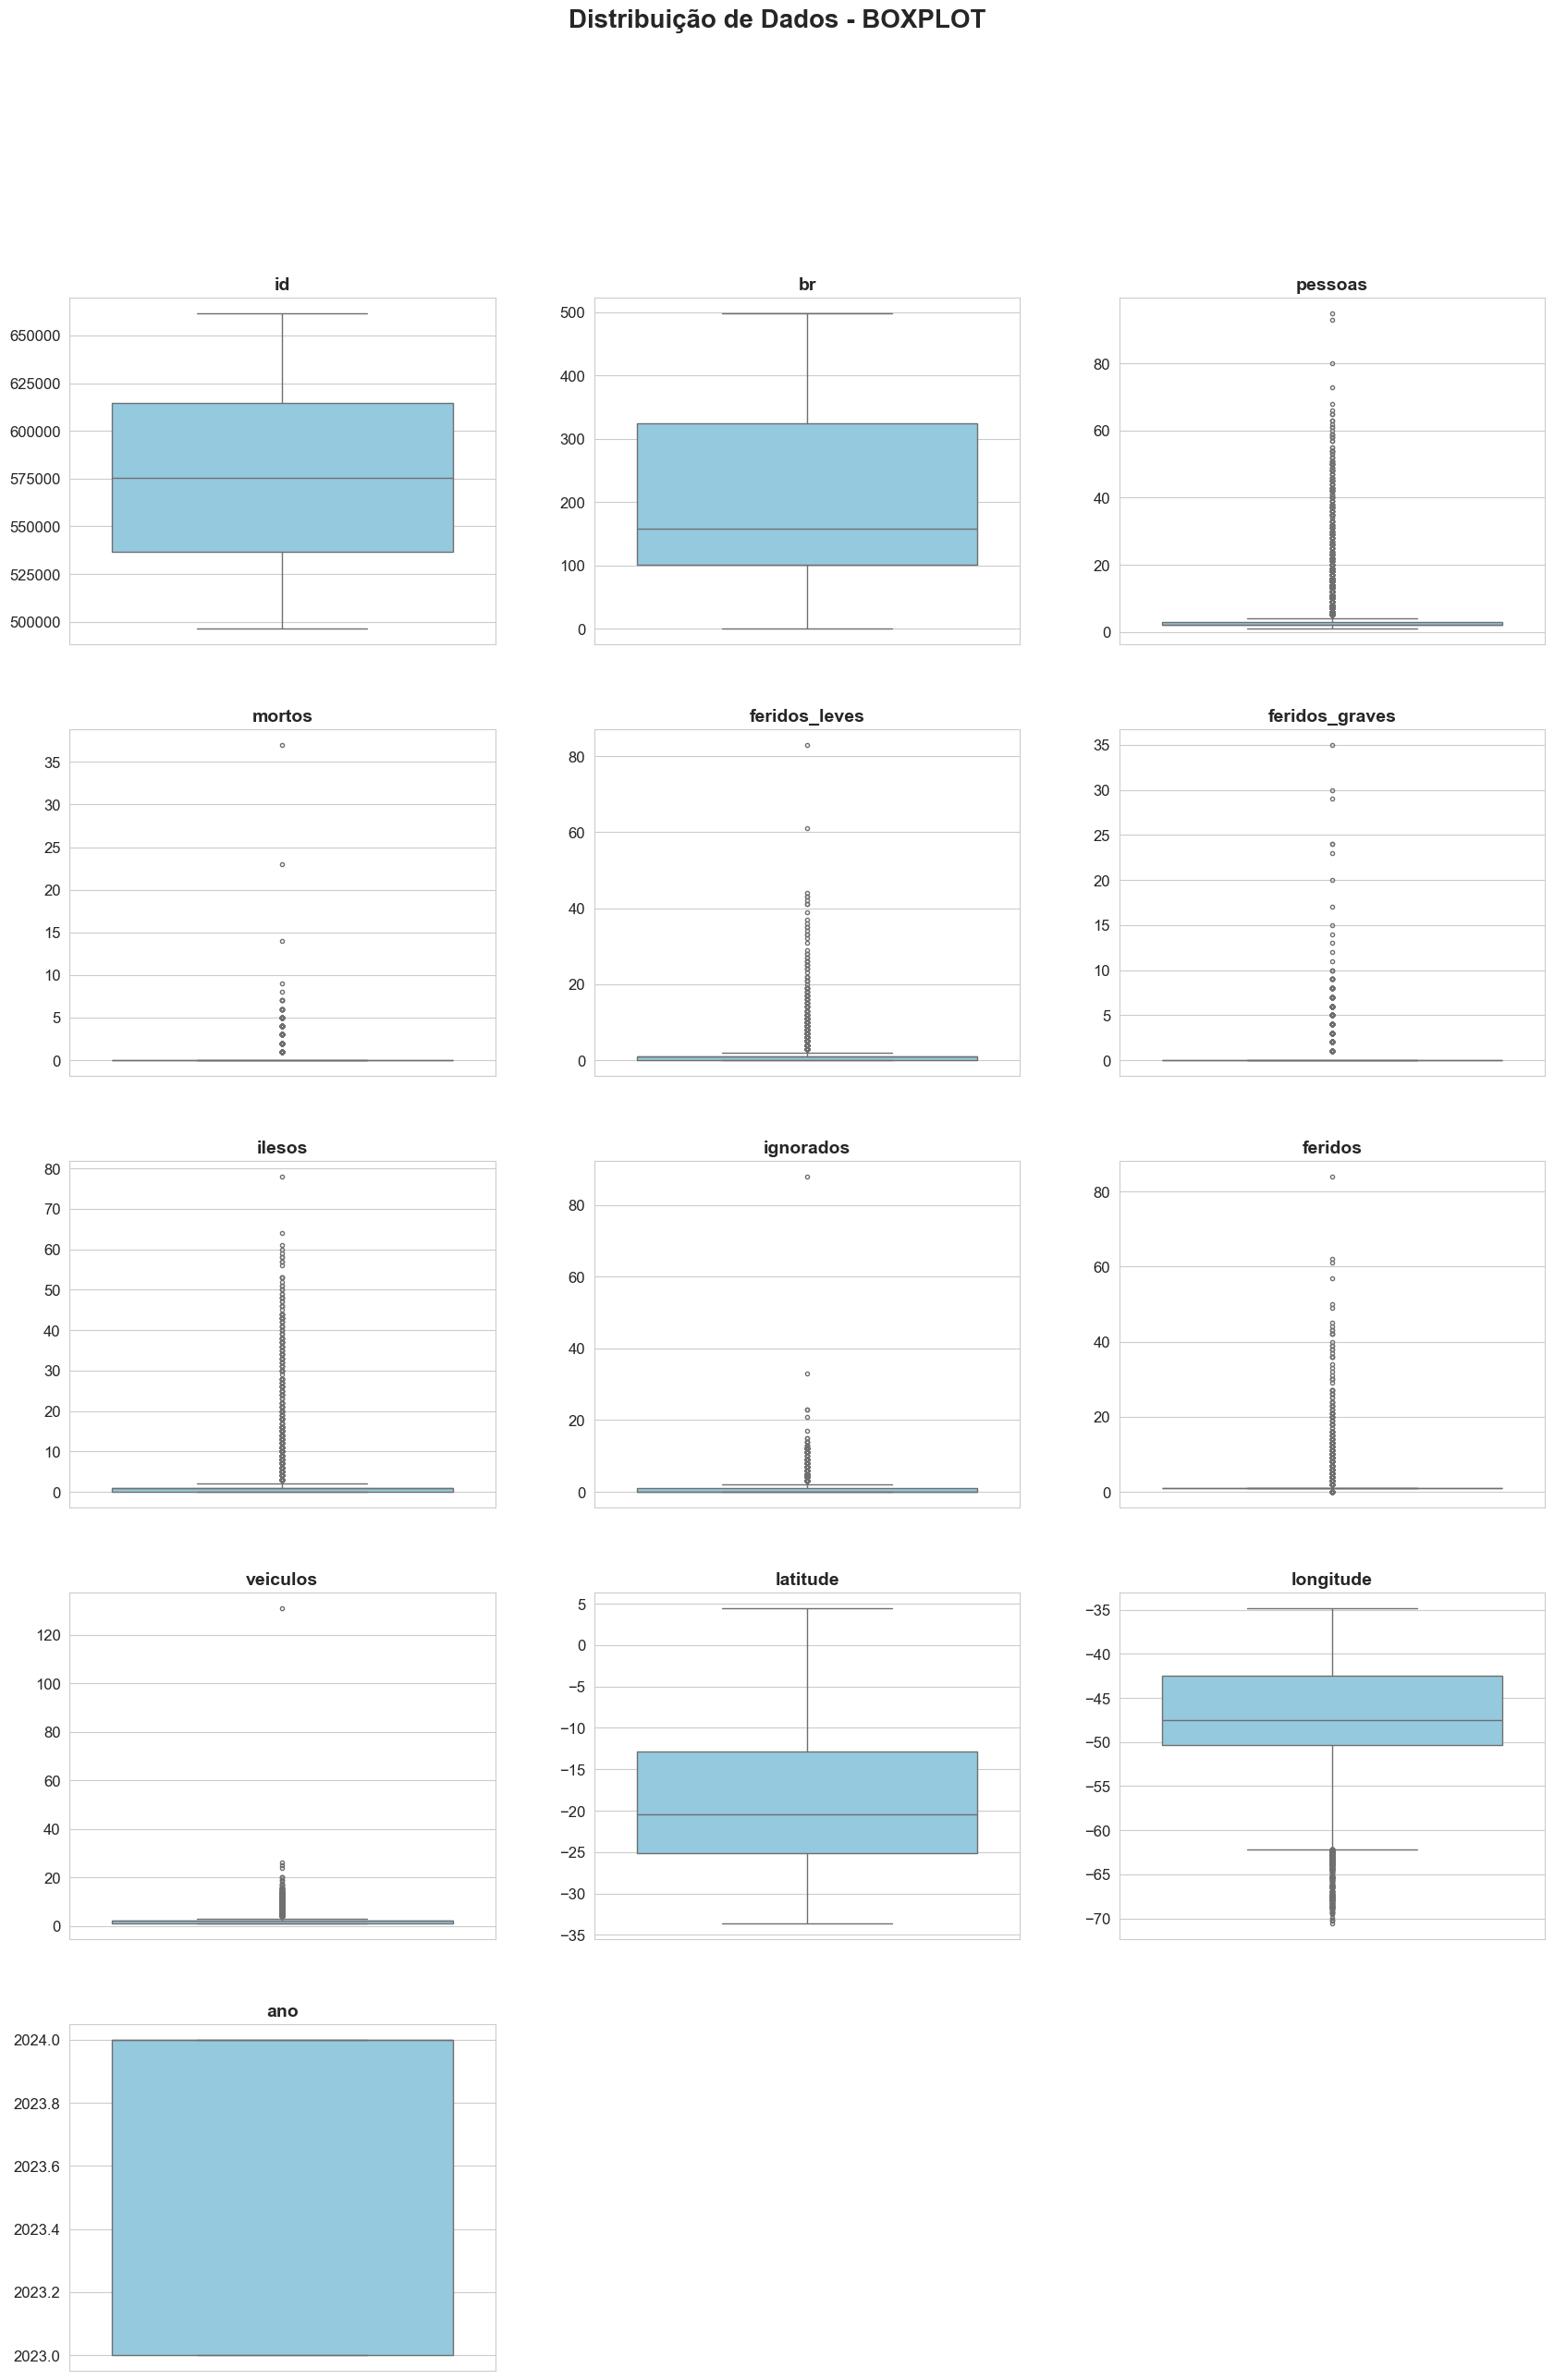

In [ ]:
def box_plot(dataframe: pd.DataFrame):
    """
    Plota BoxPlots estilizados com título simplificado para todas as variáveis numéricas do DataFrame fornecido
    em um grande painel com 3 gráficos por linha.

    :param Dataframe: DataFrame para quais os boxplots serão gerados
    """

    # Seleciona apenas colunas numéricas
    colunas_numericas = dataframe.select_dtypes(include=[np.number]).columns

    # define o total de linhas do painel gráfico baseado na quantidade de colunas numéricas
    nrows = len(colunas_numericas) // 3 + (len(colunas_numericas) % 3 > 0)   # a partir do +, ele vai somar mais uma linha caso o resto da div seja > 0.

    # inicializando o painel de gráficos
    fig, axes = plt.subplots(nrows=nrows, ncols=3, figsize=(18, nrows * 5)) # cria uma figura e uma matriz de eixos.
    
    axes = np.ravel(axes) # transforma qualquer formato em uma lista linear de eixos

    # configura o estilo e paleta de cores
    sns.set_style('whitegrid')

    # plota os boxplots para cada coluna numérica
    for i, coluna in enumerate(colunas_numericas):
        sns.boxplot(data= dataframe[coluna], ax= axes[i], color='skyblue', fliersize=3)
        axes[i].set_title(f'{coluna}', fontdict={'fontsize':14, 'fontweight':'bold'})
        axes[i].set_ylabel('')
        axes[i].tick_params(axis='both', which='major', labelsize=12) # ajusta o tamanho dos rótulos dos eixos

    # Remove gráficos vazios se houver (caso o número de colunas não seja múltiplo de 3)
    for j in range(i+1, len(axes)):
        fig.delaxes(axes[j])  # axes.flatten = transforma a matriz de eixos em uma lista linear

    # adiciona título principal
    fig.suptitle('Distribuição de Dados - BOXPLOT', fontweight='bold', fontsize=20, y=1.05) #y=1.05 posiciona o título um pouco acima

     # ajustando o layout
    plt.tight_layout(pad=5) # espaçamento de 5 entre os gráficos
    plt.show()

# Plotando os boxplots conforme a função foi definida
box_plot(df_prf)
    

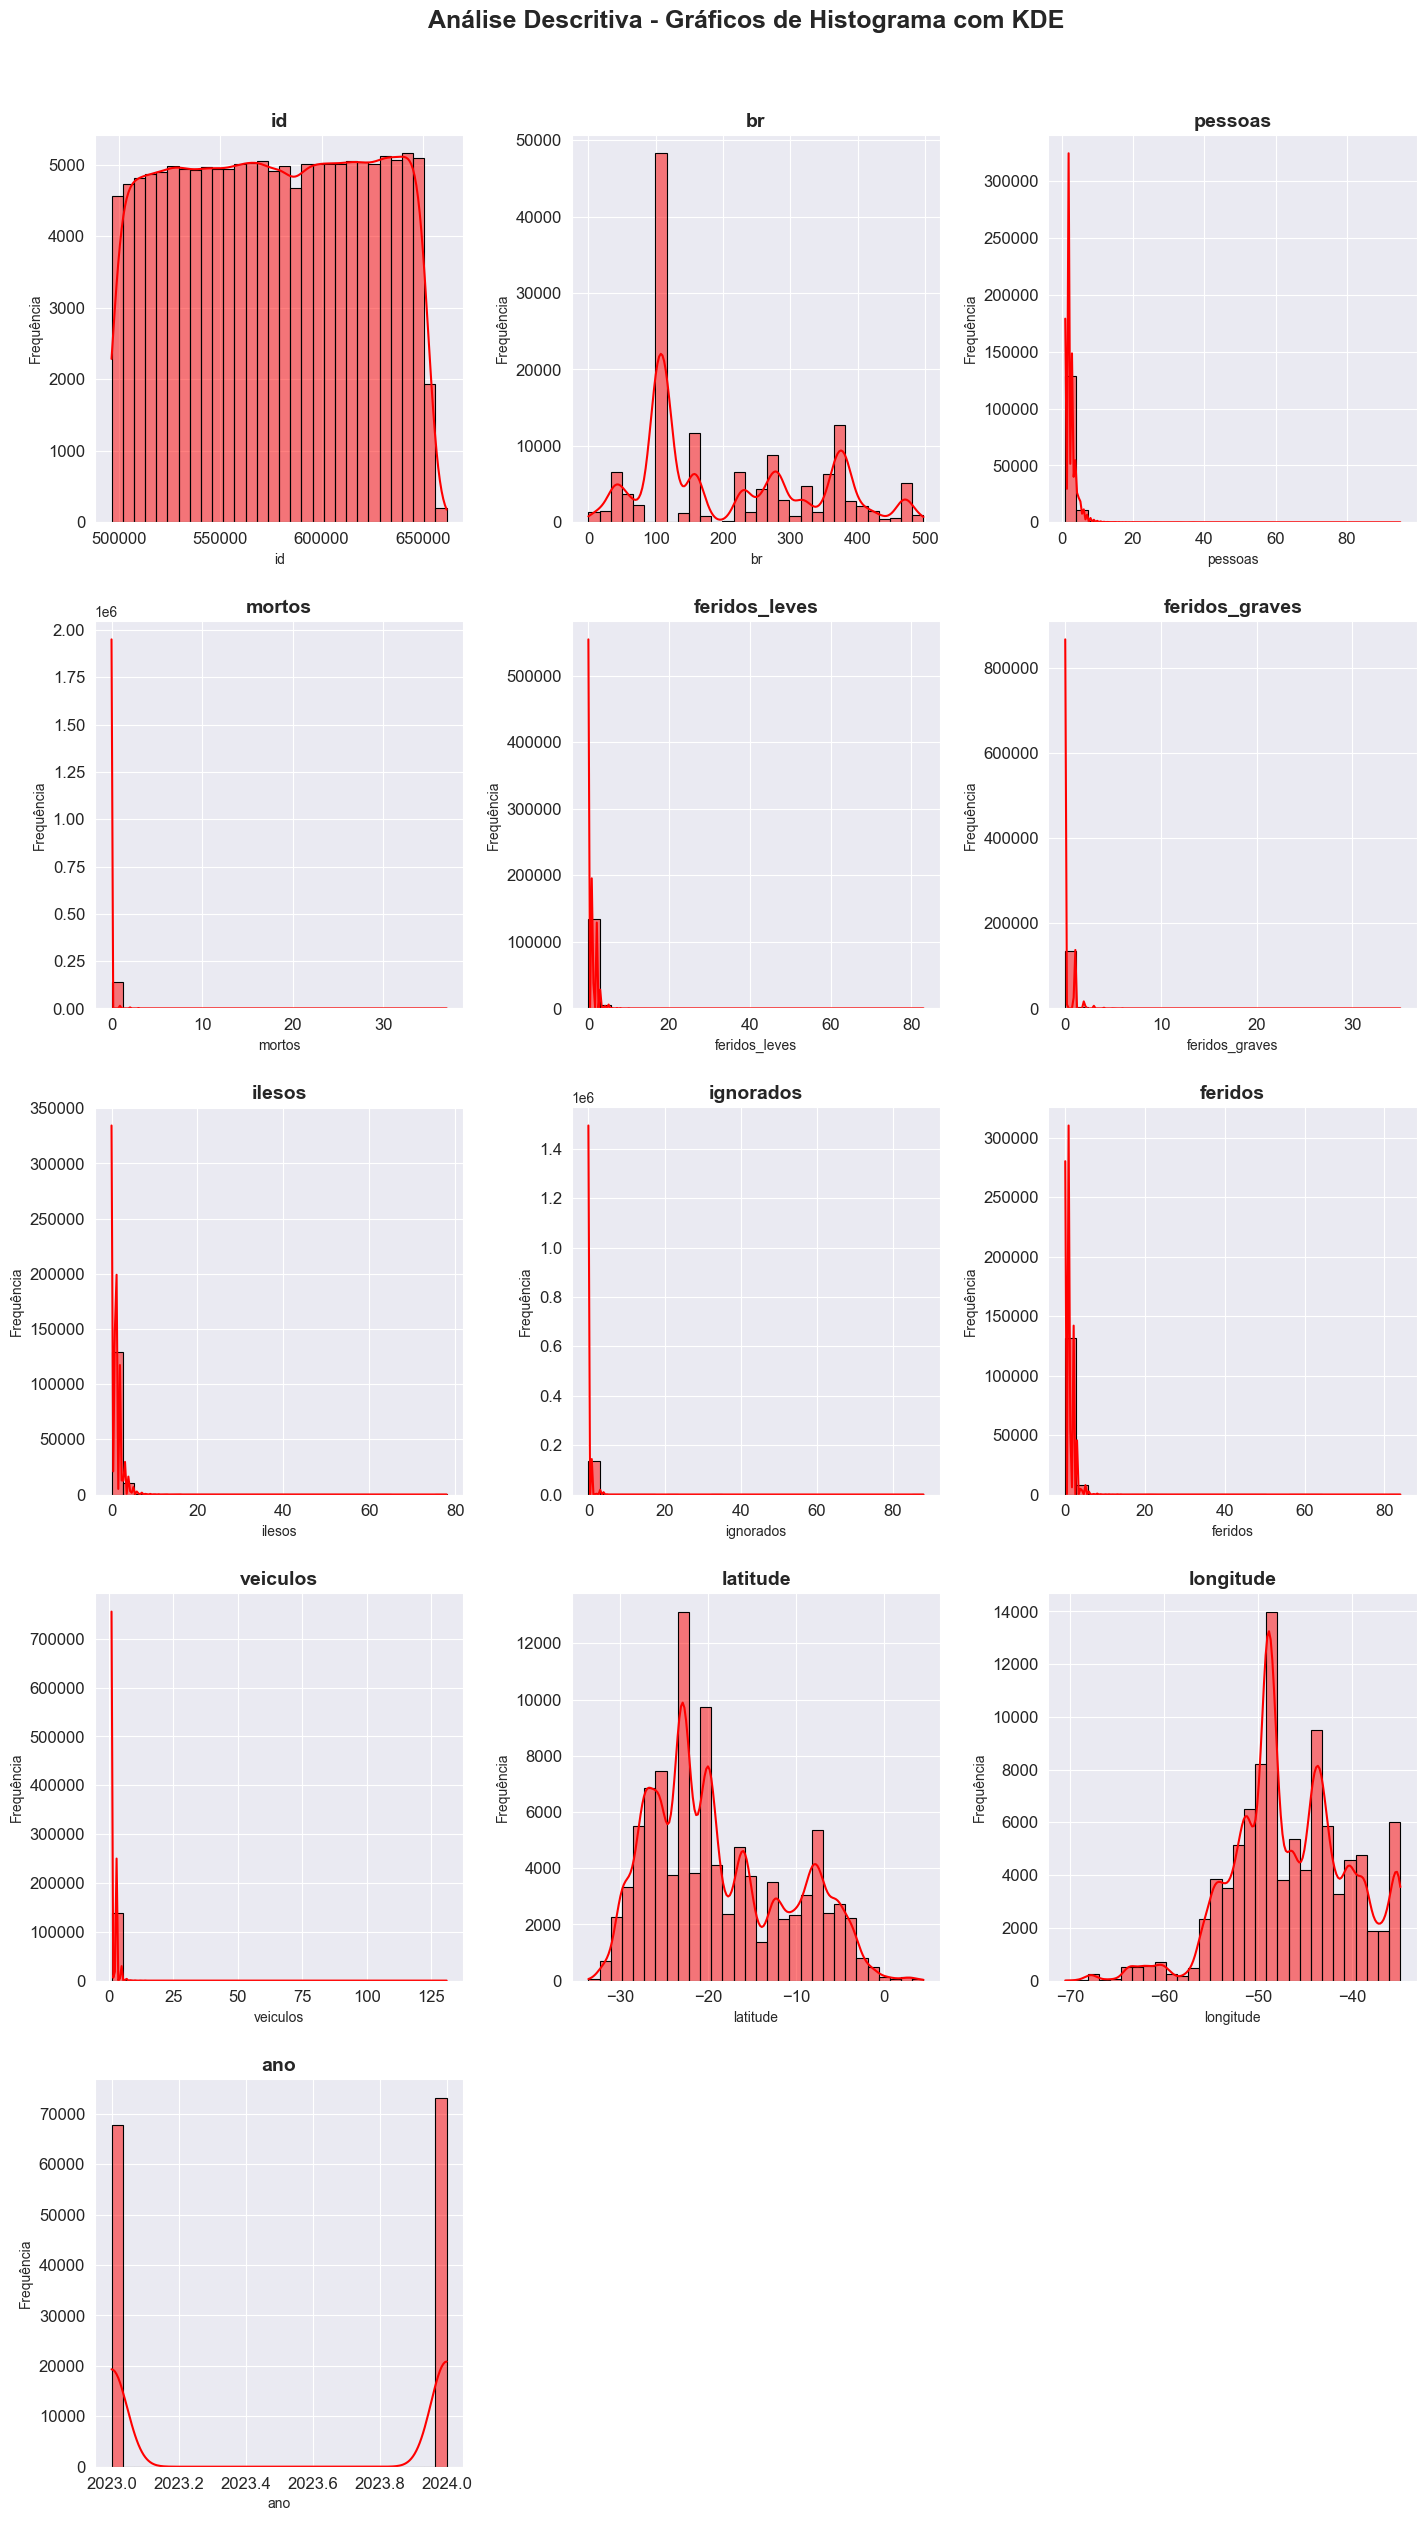

In [ ]:
def histograma(dataframe: pd.DataFrame):
    """
    Plota os gráficos de histograma corrigidos com a curva KDE para todas as variáveis numéricas
    do dataframe fornecidos em um painel com 3 gráficos por linhas.

    :param dataframe: Dataframe para o qual os histogramas serão gerados.    
    """

    # Selecionando somente colunas numéricas
    colunas_numericas = dataframe.select_dtypes(include=[np.number]).columns    

    # Define o total de linhas do painel gráfico baseado na quantidade de colunas numéricas
    nrows = len(colunas_numericas) // 3 + (len(colunas_numericas) % 3 > 0)

    # Inicializando o painel dos gráficos
    fig, axes = plt.subplots(nrows=nrows, ncols=3, figsize=(15, nrows * 5))

    sns.set_style('darkgrid')

    # Plota os histogramas com KDE para cada coluna numérica
    for i, coluna in enumerate(colunas_numericas):
        sns.histplot(data=dataframe[coluna], ax=axes[i//3, i%3], color='red', bins=30, kde=True, edgecolor='black')
        axes[i//3, i%3].set_title(f'{coluna}', fontdict={'fontsize':14, 'fontweight':'bold'})
        axes[i//3, i%3].set_ylabel('Frequência')
        axes[i//3, i%3].tick_params(axis='both', which='major', labelsize=12)

    # Removendo gráficos em branco (se houver)
    for j in range(i+1, nrows*3):
        fig.delaxes(axes.flatten()[j])

    # Adiciona título principal
    fig.suptitle('Análise Descritiva - Gráficos de Histograma com KDE', fontsize= 18, fontweight='bold', y=1.02)

    # Ajustando o layout
    plt.tight_layout(pad=5)
    plt.show()

histograma(df_prf)

In [21]:
# Analisando o registro do outlier da quantidade de veículos
registro = df_prf.loc[df_prf['veiculos'] > 120]

print(registro.T)

                                     17558
id                                595429.0
data_inversa                    2023-09-02
dia_semana                          sábado
horario                           14:20:00
uf                                      PR
br                                     277
km                                     136
municipio                       BALSA NOVA
causa_acidente                     Neblina
tipo_acidente             Colisão traseira
classificacao_acidente  Com Vítimas Fatais
fase_dia                         Pleno dia
sentido_via                      Crescente
condicao_metereologica    Nevoeiro/Neblina
tipo_pista                           Dupla
tracado_via                  Declive;Curva
uso_solo                               Não
pessoas                                 95
mortos                                   5
feridos_leves                            6
feridos_graves                           6
ilesos                                  38
ignorados  

In [30]:
def outliers_report(df: pd.DataFrame):
    """
    Gera um relatório com a quantidade e o percentual de Outliers
    nas colunas numéricas, usando o método do IQR.
    
    :pam = recebe o Dataframe
    :return = Dataframe com resumo de outliers por variável.
    """

    #Selecionando colunas numéricas
    colunas_numericas = df.select_dtypes(include=[np.number]).columns
    relatorio = []

    for coluna in colunas_numericas:
        # Remove os nulos para cálculos
        serie = df[coluna].dropna()
        
        # Pular colunas vazias
        if serie.empty:
            continue

        # Calcula Quartis e IQR   
        Q1 = serie.quantile(0.25)
        Q3 = serie.quantile(0.75)
        IQR = Q3 - Q1

        # Define Limites Superior e Inferior
        limite_inferior = Q1 - 1.5 * IQR
        limite_superior = Q3 + 1.5 * IQR

        # Identificando outliers
        outliers = serie[(serie < limite_inferior) | (serie > limite_superior)]
        percentual = (len(outliers) / len(serie)) * 100

        # Gerando o relatório
        relatorio.append({
            'Coluna':coluna,
            'Qtd_Total': len(serie),
            'Qtd_Outliers': len(outliers),
            'Percent_Outliers': round(percentual, 2),
            'Limite_Superior': round(limite_superior, 2),
            'Limite_Inferior': round(limite_inferior, 2)
        
        })

    relatorio_df = pd.DataFrame(relatorio).sort_values(by='Percent_Outliers', ascending=False).reset_index(drop=True)
    return relatorio_df

outliers_report(df_prf)

,Coluna,Qtd_Total,Qtd_Outliers,Percent_Outliers,Limite_Superior,Limite_Inferior
0,feridos,140922,61446,43.60,1.00,1.00
1,feridos_graves,140922,31992,22.70,0.00,0.00
2,pessoas,140922,12694,9.01,4.50,0.50
3,ilesos,140922,12254,8.70,2.50,-1.50
4,veiculos,140922,10247,7.27,3.50,-0.50
5,mortos,140922,10080,7.15,0.00,0.00
6,feridos_leves,140922,6029,4.28,2.50,-1.50
7,ignorados,140922,3860,2.74,2.50,-1.50
8,longitude,98304,1430,1.45,-30.70,-62.19
9,br,140922,0,0.00,658.50,-233.50


**Variabilidade e Distribuição:**
- Variáveis como pessoas, mortos, feridos leves, feridos graves, ilesos, feridos e ignorados têm a maioria de seus valores concentrados perto de zero, indicando que muitos incidentes envolvem nenhum ou poucas vítimas. No entanto, existem alguns valores atipicamente altos para essas variáveis, sugerindo que, embora raros, existem acidentes com um quantidade considerável de vítimas.

**Outliers:**
- Muitas das variáveis apresentam outliers. Estes são pontos que caem fora das "antenas" do boxplot e podem indicar valores atipicamente altos ou baixos. Por exemplo, a variável pessoas tem vários valores que são consideravelmente mais altos do que a mediana, sugerindo incidentes com um número anormalmente alto de pessoas envolvidas.
Os outliers podem indicar tanto erros de entrada de dados quanto eventos reais que são atípicos. Eles podem ser investigados mais a fundo para entender sua natureza.

**Concentração de Dados:**
- A linha central (mediana) dos boxplots das variáveis: ilesos, feridos graves, feridos leves e mortos esta no valor zero. Isso indica que a maioria dos incidentes não resultam em ferimentos ou mortes.

**Amplitude dos Dados:**
- O intervalo interquartil (IQR), que é a altura da caixa no boxplot, indica onde reside a metade central dos dados. Para muitas das variáveis, o IQR é pequeno, mostrando que os valores estão concentrados. Por outro lado, uma caixa maior indica maior variabilidade nos dados.

**Tendências e Anomalias:**
- Se os dados estivessem distribuídos em grupos ou categorias (como diferentes estados ou tipos de incidentes), poderíamos usar boxplots para comparar essas categorias e identificar tendências ou anomalias específicas de cada grupo.
Estes são insights gerais que podem ser obtidos a partir dos boxplots. Para insights mais específicos ou detalhados, seria útil combinar a análise visual dos boxplots com outras técnicas estatísticas e métodos de visualização.

### Análisando todas as colunas numéricas por Histograma

### Análisando dados da frequência de acidentes por horários dos dias

O código a seguir vamos montar um histograma com a frequência de acidentes por horários do dia.

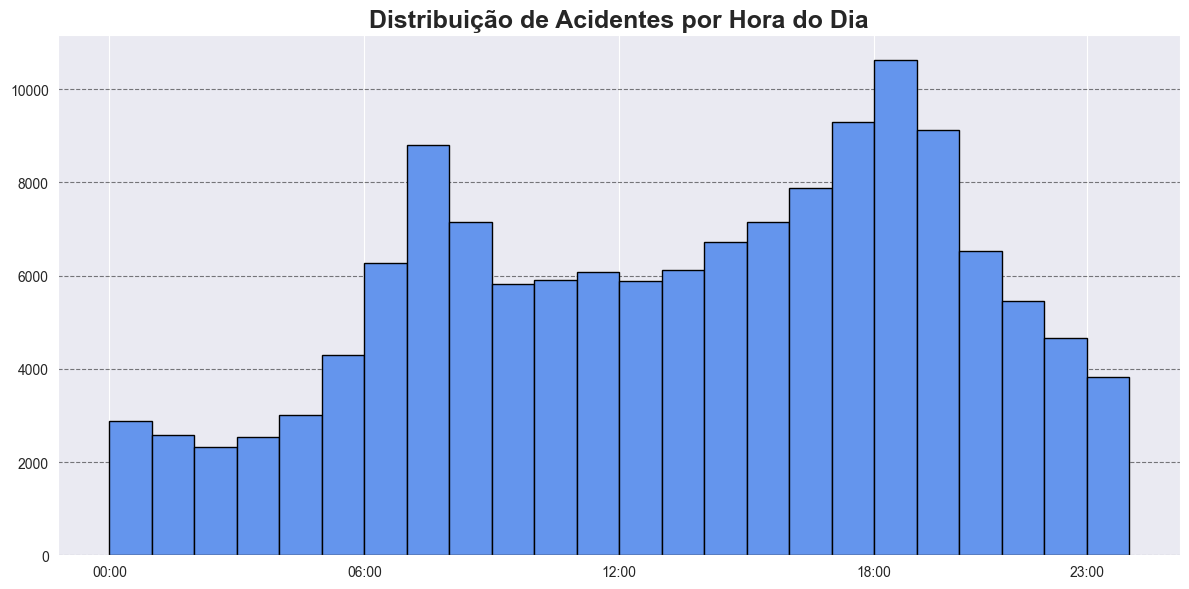

In [23]:
# criando uma copia e convertendo em Datatime
df_horas = df_prf.copy()
df_horas['horario'] = pd.to_datetime(df_horas['horario'], format='%H:%M:%S', errors='coerce')

# Extraindo a hora da coluna horário
df_horas['hora'] = df_horas['horario'].dt.hour

# criando o gráfico
plt.figure(figsize=(12, 6))
sns.set_style('darkgrid')

#plotando o histograma com os horários
plt.hist(df_horas['hora'],
        bins=24,
       range=(0,24),
        color='cornflowerblue',
       edgecolor='black'
)

plt.title('Distribuição de Acidentes por Hora do Dia', fontsize=18, fontweight='bold')
plt.ylabel('')

# Formatando os rótulos do eixo x
plt.xticks([0, 6, 12, 18, 23], ['00:00', '06:00', '12:00', '18:00', '23:00'])

# Função para ativar as linhas de grades
plt.grid(axis='y', linestyle='--', alpha=0.5, color='black') # y = linha será aplicada somente na vertical

plt.tight_layout()
plt.show()

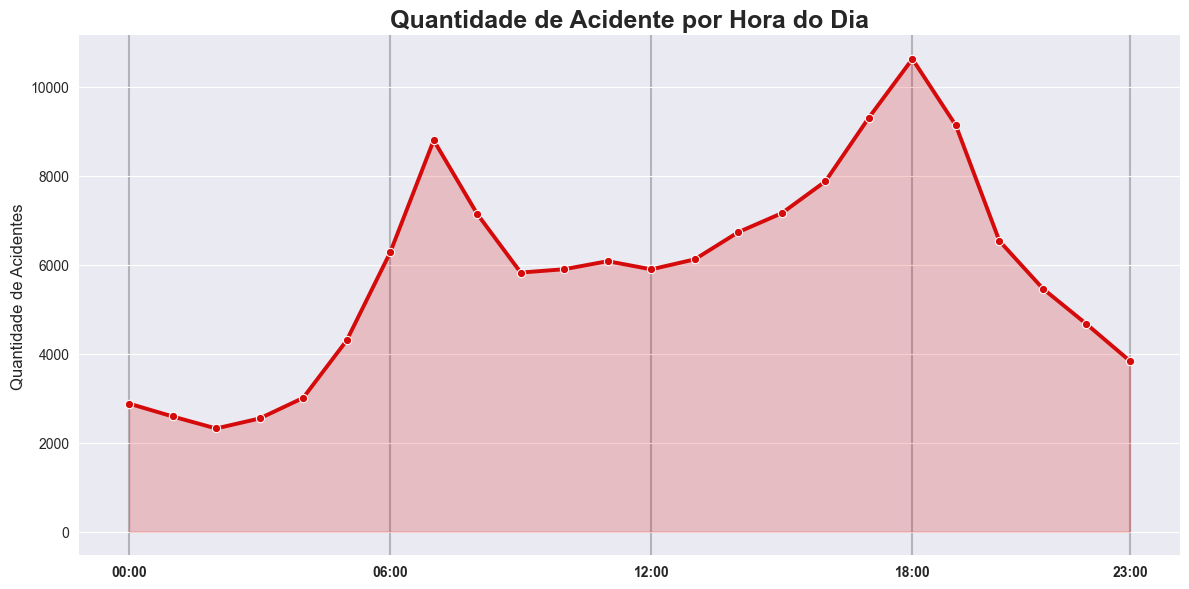

In [24]:
# Agrupando os acidentes por hora
acidente_por_hora = pd.DataFrame(
    df_horas
    .groupby('hora')
    .size()
    .reset_index(name='quantidade')
)

plt.figure(figsize=(12,6))
sns.set_style('darkgrid')

cor_principal = "#D50A0A"

# Plotando gráfico de linhas no SEABORN
sns.lineplot(
    data=acidente_por_hora,
    x='hora',
    y='quantidade',
    marker='o',
    color=cor_principal,
    linewidth= 2.8
)

# Preenchendo o gráfico com uma sombra abaixo da linha
plt.fill_between(
    acidente_por_hora['hora'],
    acidente_por_hora['quantidade'],
    color=cor_principal,
    alpha=0.2
)

# Título e Labels
plt.title('Quantidade de Acidente por Hora do Dia', fontsize=18, fontweight='bold')
plt.ylabel('Quantidade de Acidentes', fontsize=12)
plt.xlabel('')

# Ajustando rótulos do eixo x
plt.xticks(
    [0, 6, 12, 18, 23],
    ['00:00', '06:00', '12:00', '18:00', '23:00'],
    fontsize= 10,
    fontweight='bold'
)

# Ajustando eixos e grade
plt.grid(axis='x', linestyle='-', alpha=0.5, color='gray', linewidth=1.5) # linhas no eixo x para visualizar melhor: madrugada, manhã, tarde e noite
sns.despine(left=True, bottom=True) # remove as bordas

plt.tight_layout()
plt.show()

O código a seguir vamos análisar essa frequência de acidentes por dias da semana (utilizando o HeatMap)

In [25]:
# Agrupando a quantidade por dias da semana
dias_da_semana = pd.DataFrame(
    df_horas
    .groupby(['dia_semana', 'hora'])
    .size()
    .reset_index(name='quantidade')
)

# Ordenação dos dias da semana. ex: segunda, terça, quarta ...
ordem_dias = [
    'segunda-feira', 'terça-feira', 'quarta-feira', 'quinta-feira', 'sexta-feira', 'sábado', 'domingo'
]

# Ordenando
dias_da_semana['dia_semana'] = pd.Categorical(
    dias_da_semana['dia_semana'],
    categories=ordem_dias,
    ordered=True
)

# Agora ordenada com base nessa ordem
dias_da_semana = dias_da_semana.sort_values('dia_semana')
dias_da_semana

,dia_semana,hora,quantidade
83,segunda-feira,11,888
93,segunda-feira,21,559
92,segunda-feira,20,719
91,segunda-feira,19,1108
90,segunda-feira,18,1437
...,...,...,...
21,domingo,21,1019
22,domingo,22,805
23,domingo,23,650
12,domingo,12,808


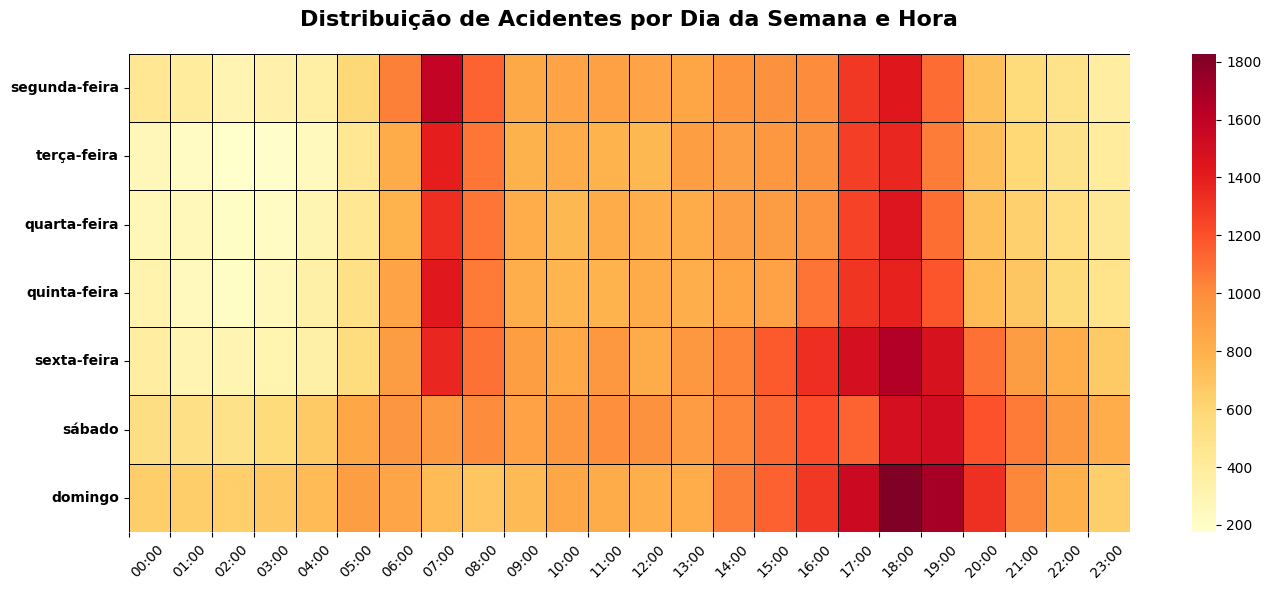

In [26]:
# Criando uma tabela dinâmica com dias x horas
tabela_calor = dias_da_semana.pivot(index='dia_semana', columns='hora', values='quantidade')

# lista com todos os rótulos das horas para utilizar no xticks
cols = list(tabela_calor.columns)

# Criando a figura
plt.figure(figsize=(14, 6))

# cor do fundo do gráfico
plt.style.use('default')

sns.heatmap(
    tabela_calor,
    cmap='YlOrRd', # tons -> amarelo, laranja e vermelho
    linecolor='black',
    linewidths=0.5, # separação entre os quadros
) 

plt.title('Distribuição de Acidentes por Dia da Semana e Hora', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('')
plt.ylabel('')

# Ajustando rótulos dos eixos
plt.yticks(fontweight='bold') # eixo y
plt.xticks(                   # eixo x
    ticks=range(len(cols)),
    labels=[f'{int(h):02d}:00'  for h in cols],
    rotation=45,
    ha='left'
)

plt.tight_layout()
plt.show()

### Análisando as colunas categóricas utilizando o Gráfico de Barras

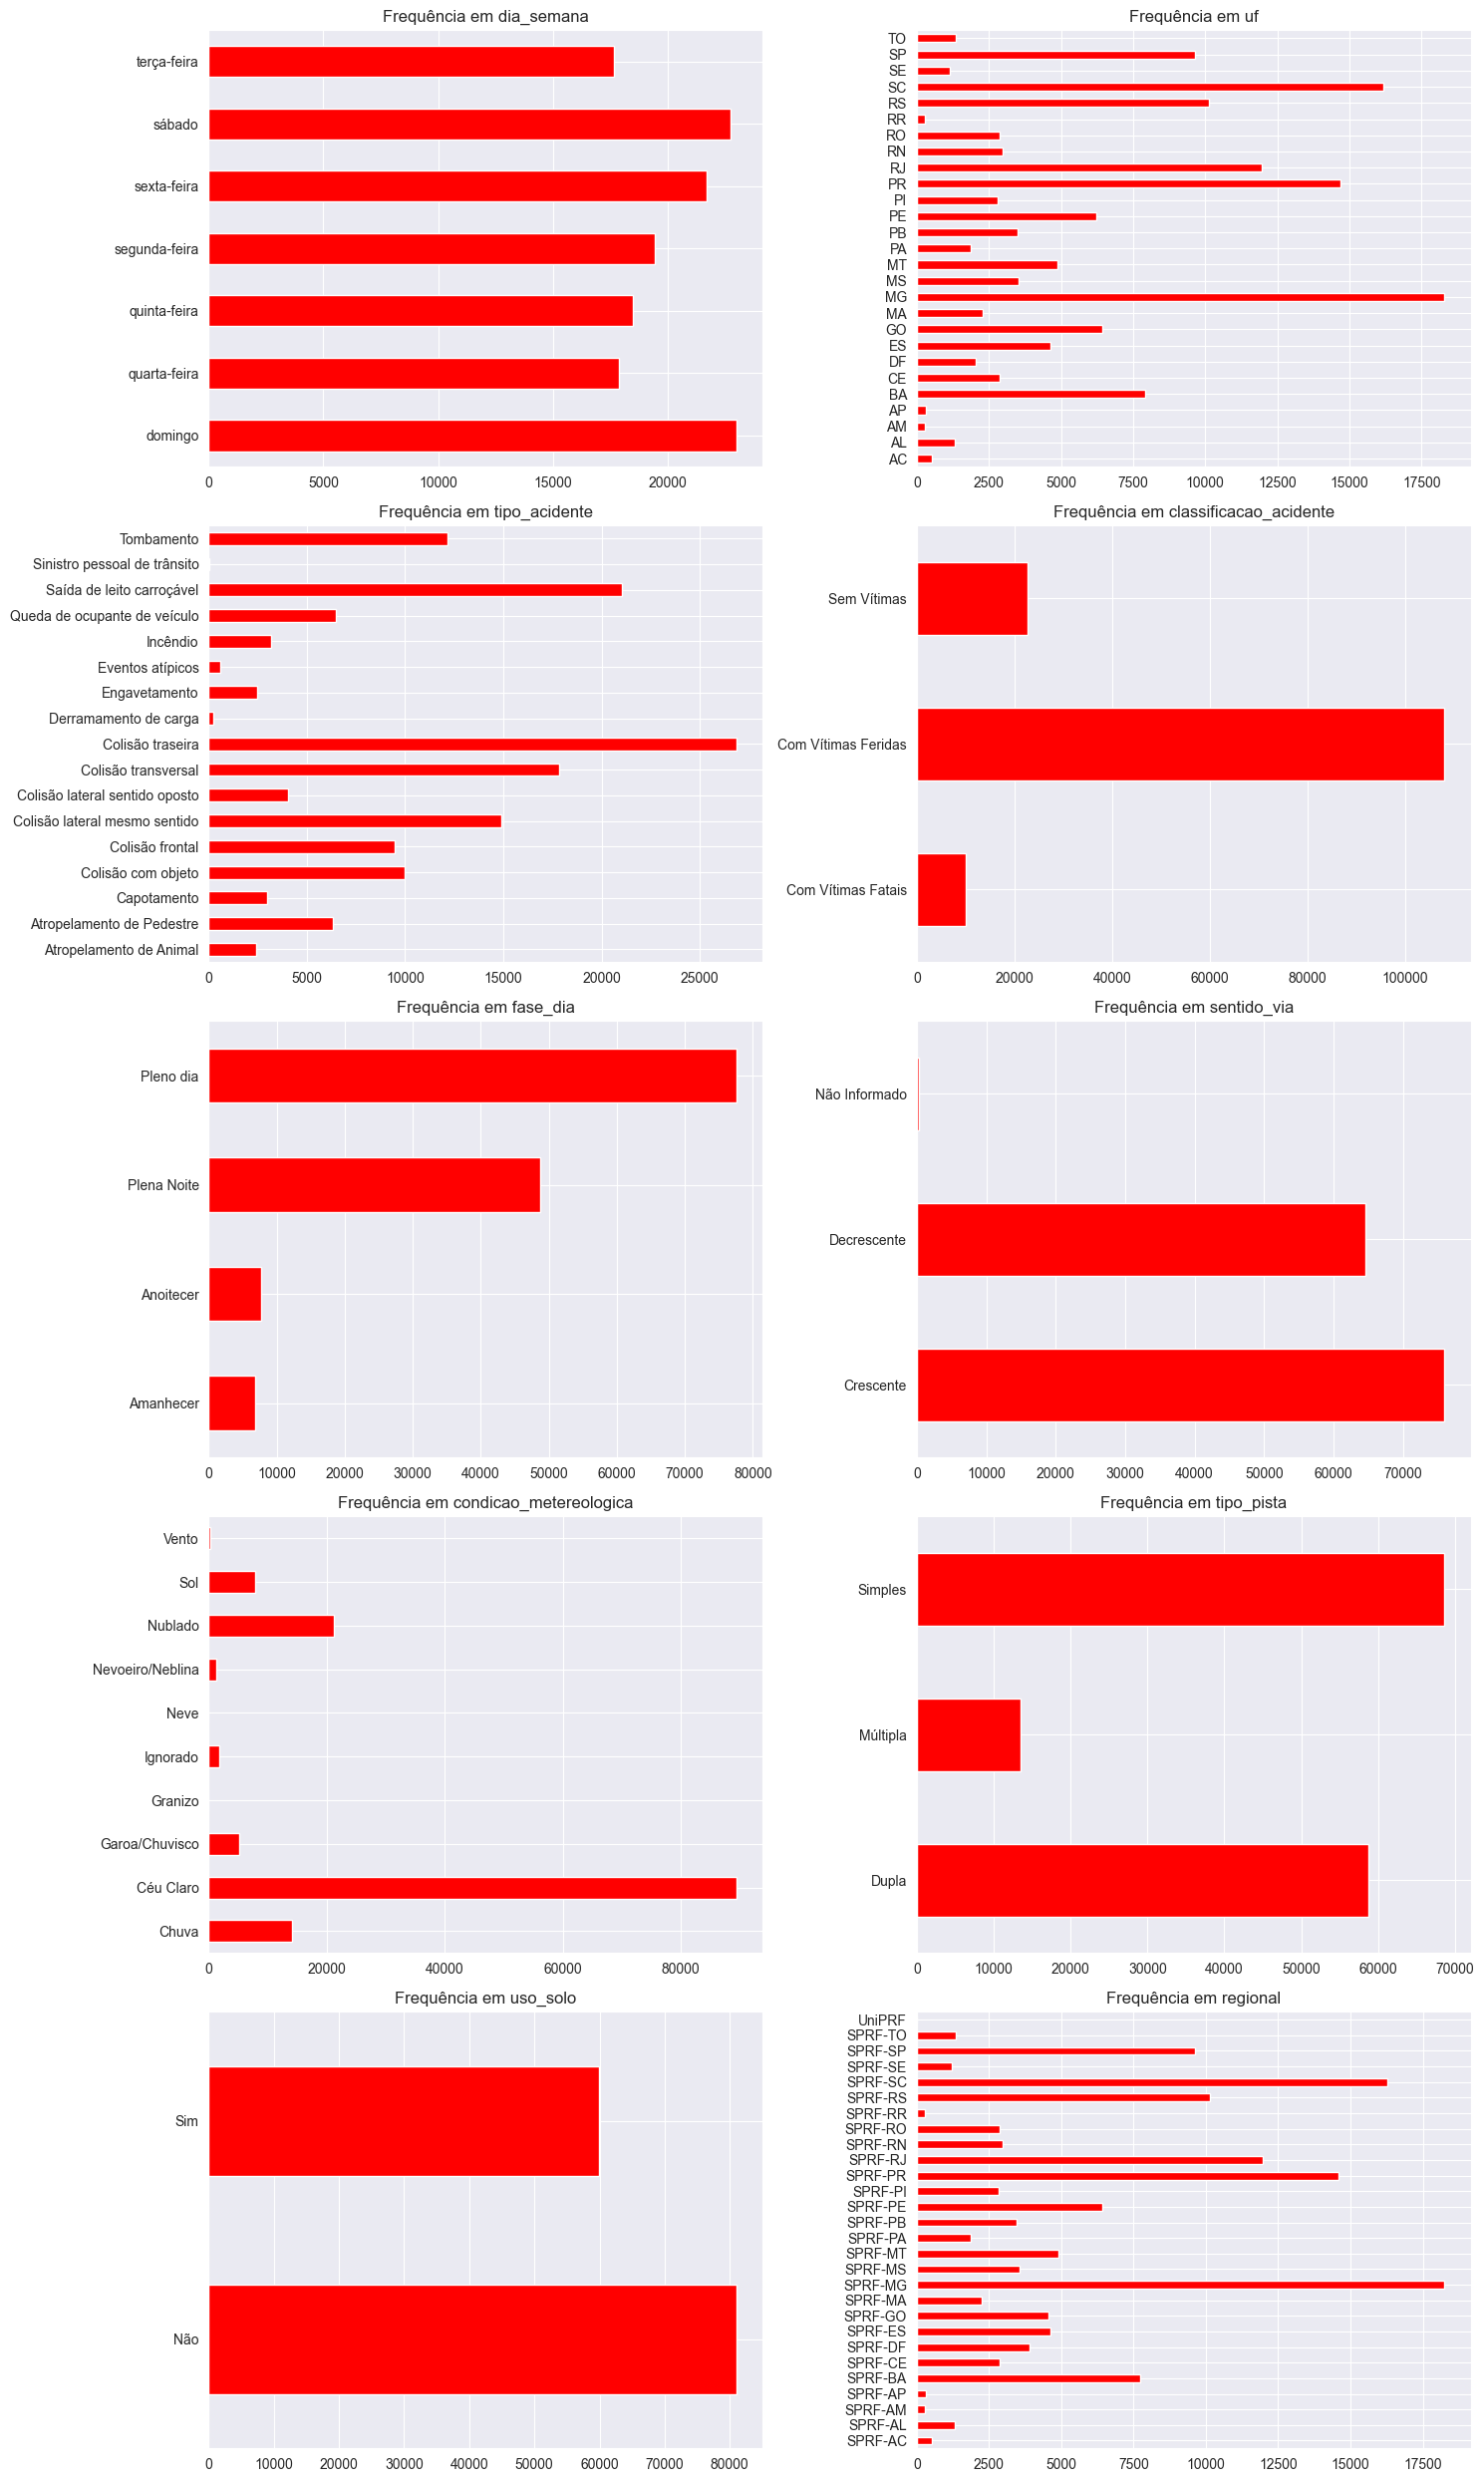

In [27]:
def categorical_frequency(df: pd.DataFrame, corte_cardinalidade=30, graficos_por_linha=2):
    """
    Plota a frequência de categorias para variáveis categóricas de um Dataframe.
    
    parâmetros:
    df: Dataframe para plotagem
    corte_cardinalidade: Quantidade de cardinalidade por coluna (padrão 30)
    graficos_por_linha: Quantidade de gráficos por linha (padrão é 2)

    Retorno:
    Exibe o gráfico de barras
    """

    # Gerando metadados para o Dataframe
    metadados= []
    for coluna in df.columns:
        metadados.append({
            'variavel': coluna,
            'tipo': df[coluna].dtype,
            'cardinalidade': df[coluna].nunique()
        })

    df_metadados = pd.DataFrame(metadados)

   
    sns.set_style('darkgrid')

    # Filtra colunas com a cardinalidade maior que o corte e tipos não numéricos
    variaveis_categoricas = df_metadados[(df_metadados['tipo'] == 'object') & (df_metadados['cardinalidade'] <= corte_cardinalidade)]
    
    # Calcula a quantidade de linhas e colunas para os subplots
    nlinhas = -(-len(variaveis_categoricas) // graficos_por_linha) # Ceiling Division
    ncolunas = min(graficos_por_linha, len(variaveis_categoricas))

    # Plota as variáveis categóricas
    fig, axs = plt.subplots(nrows=nlinhas, ncols=ncolunas, figsize=(15, 5*nlinhas)) # 15 de largura e 5 de altura por linha

    for i, (idx, linha) in enumerate(variaveis_categoricas.iterrows()): #iterrows = percorre linha por linha do Dataframe
        var = linha['variavel']
        ax = axs[i // graficos_por_linha, i % graficos_por_linha]
        df[var].value_counts().sort_index().plot(kind='barh', ax=ax, color='red')
        ax.set_title(f'Frequência em {var}')
        ax.set_ylabel('')
        ax.set_xlabel('')

    # Remove os eixos vazios se houver
    for j in range(i+1, nlinhas*ncolunas):
        axs[j // graficos_por_linha, j % graficos_por_linha].axis('off')

    plt.tight_layout()
    plt.show()


# Testando a função com o Dataframe e os parâmetros DEFAULT
categorical_frequency(df_prf)


**Dias da Semana (dia_semana)**:
- A maioria dos registros parece ocorrer nos finais de semana (sábado e domingo). Isso pode indicar um aumento de atividades ou eventos que resultam em mais registros nesses dias.

**UF (Estados)**:
- Alguns estados têm uma contagem mais alta de registros em comparação com outros. É essencial considerar a população e o tamanho de cada estado ao interpretar esses dados. Por exemplo, estados mais populosos ou com maiores redes rodoviárias podem naturalmente ter mais registros.

**Causa do Acidente (causa_acidente)**:
- Alguns motivos parecem ser mais predominantes que outros. Por exemplo, "Falta de atenção" e "Desobediência às normas de trânsito" parecem ser causas comuns, o que pode indicar a necessidade de campanhas de conscientização.

C**lassificação do Acidente (classificacao_acidente)**:
- A maioria dos acidentes parece ser sem vítimas ou com feridos leves, o que é uma boa notícia. No entanto, ainda há uma quantidade significativa de acidentes com feridos graves e mortos, ressaltando a importância da segurança no trânsito.

**Fase do Dia (fase_dia)**:
- Os acidentes parecem ser mais comuns durante o dia, com uma quantidade considerável durante a noite.

**Condição Meteorológica (condicao_metereologica)**:
- A maioria dos registros ocorre em condições claras, o que é esperado, mas também destaca que condições adversas, como chuva ou neblina, não são os principais contribuintes para os acidentes, embora possam aumentar sua gravidade.

**Tipo de Pista (tipo_pista)**:
- A maioria dos registros ocorre em pistas simples, o que pode indicar que essas pistas apresentam mais riscos ou que são mais comuns nas áreas abrangidas pelos dados.

In [28]:
df_prf_causas_acidentes = df_prf.copy()

df_prf_causas_acidentes = pd.DataFrame(
    df_prf_causas_acidentes
    .groupby(['causa_acidente', 'tipo_acidente'])
    .size()
    .reset_index(name='quantidade')
)

df_prf_causas_acidentes.sort_values(ascending=False, by=['quantidade']).head(40)

,causa_acidente,tipo_acidente,quantidade
7,Acessar a via sem observar a presença dos outr...,Colisão transversal,8702
209,Condutor deixou de manter distância do veículo...,Colisão traseira,6527
119,Ausência de reação do condutor,Colisão traseira,5908
716,Reação tardia ou ineficiente do condutor,Colisão traseira,5580
527,Manobra de mudança de faixa,Colisão lateral mesmo sentido,4452
722,Reação tardia ou ineficiente do condutor,Saída de leito carroçável,4317
125,Ausência de reação do condutor,Saída de leito carroçável,4308
825,Transitar na contramão,Colisão frontal,3235
318,Demais falhas mecânicas ou elétricas,Incêndio,2847
890,Velocidade Incompatível,Saída de leito carroçável,2668


Análise rápida dos 30 tipos de acidentes e causas desses acidentes com maiores frequências:

- “Acessar a via sem observar a presença dos outros veículos” aparece 8.702 vezes como causa de colisão transversal, o que já sugere um padrão fortíssimo.

- “Ausência de reação do condutor” aparece diversas vezes, em diferentes tipos de acidentes — mostrando que é uma causa recorrente e genérica.

- “Velocidade incompatível” e “ingestão de álcool” aparecem com frequência em acidentes de tombamento e saída de leito carroçável, indicando um comportamento de risco típico.

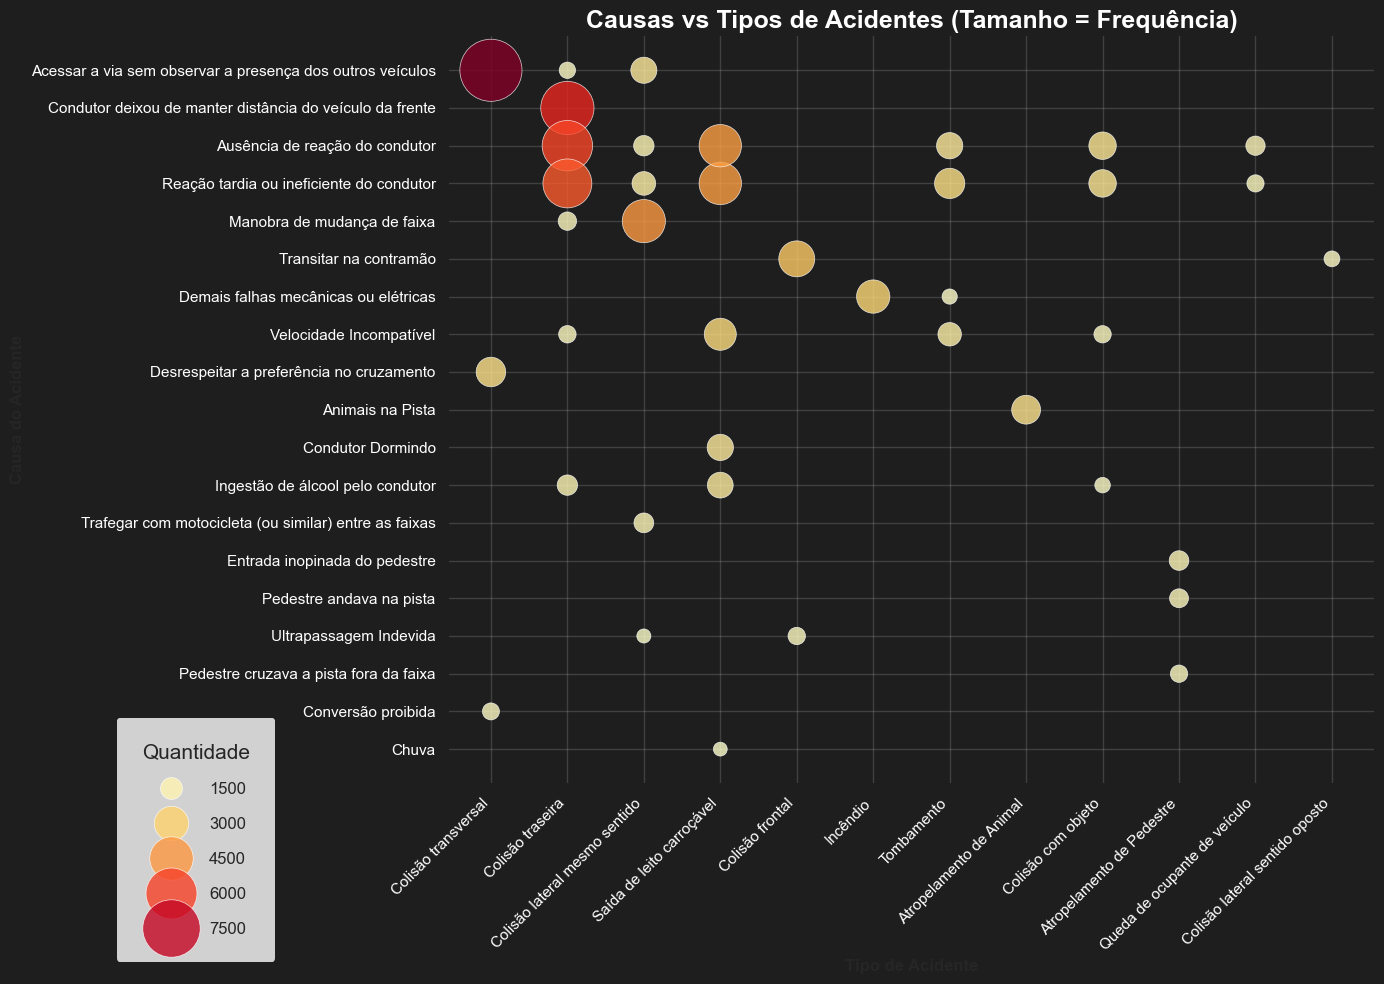

In [29]:
# Criando gráfico de bolha para análisar os dados de tipo de acidentes e suas causas.

# copiando os 40 agrupamentos com maiores frequência
df_prf_causas_acidentes_bubble = df_prf_causas_acidentes.sort_values(ascending=False, by=['quantidade']).head(40)

# Configurações de Estilo
sns.set_theme(style='whitegrid', rc={'axes.facecolor':'#1e1e1e', 'figure.facecolor': '#1e1e1e'})

# Criando o gráfico
plt.figure(figsize=(14,10))

bubble = sns.scatterplot(
    data=df_prf_causas_acidentes_bubble,
    x='tipo_acidente',
    y='causa_acidente',
    size='quantidade',
    hue='quantidade',
    palette='YlOrRd',
    alpha=0.8,              # transparência das cores
    sizes=(100, 2000),      # controla tamanho das bolhas
    edgecolor='white',      # cor das bordas das bolhas
    linewidth=0.5
)

# Ajustando as Labels
plt.title('Causas vs Tipos de Acidentes (Tamanho = Frequência)', fontsize=18, fontweight='bold', color='white')
plt.xlabel('Tipo de Acidente', fontweight='bold')
plt.ylabel('Causa do Acidente', fontweight='bold')

# Ajustando os rótulos
plt.xticks(
    rotation=45,
    ha='right',
    color='white'
)
plt.yticks(color='white')

# Remove moldura do gráfico para visual mais limpo
sns.despine(left=True, bottom=True)

# Ajustando a intensidade da cor das grades
plt.grid(alpha=0.2)

# Ajustando legenda
plt.legend(
    frameon=True,           # mantém o quadro visivel
    facecolor='white',
    edgecolor='none',
    bbox_to_anchor=(-0.17, 0.11), # posição por coordenadas ajustáveis
    
    # Ajustando fontes e tamanhos
    title='Quantidade',     # título
    title_fontsize=15,      # fonte título
    fontsize=12,            # tamanho da fonte das legendas
    labelspacing=1.2,       # espaço vertical entre os itens
    borderaxespad=1,        # espaço entre legenda e borda
    borderpad=1.5,          # espaço interno dentro do quadro
    handlelength=3,          # comprimento das bolhas (legenda)
)

plt.tight_layout()
plt.show()

**Principais Insights do Gráfico de Bolhas**

1. Causas **humanas** dominam os acidentes.

As maiores bolhas estão concentradas em causas como:
- "Acessar a via sem observar a presença dos outros veículos"
- "Condutor deixou de manter distância do veículo da frente"
- "Ausência ou reação tardia do condutor"

Isso reforça que falhas de atenção e comportamento do motorista são fatores predominantes.

2. Colisões **traseiras** e **transversais** são as mais recorrentes:

Esses tipos aparecem com mais bolhas de grande porte, indicando que são os **formatos de acidente mais frequentes**, principalmente quando combinados com distração ou desatenção do condutor.

3. Infrações específicas também geram impacto significativo

- "Manobra de mudança de faixa",  "transitar na contramão" e "velocidade incompatível" aparecem como causas intermediárias, mas ainda relevantes.
- Isso mostra que há oportunidades de prevenção com campanhas de conscientização e fiscalização voltadas a ultrapassagens e controle de velocidade.

## Análise Geográfica com Mapas

In [30]:
import geopandas as gpd

# URL do conjunto de dados `ne_110m_admin_0_countries.zip`
url = "https://naciscdn.org/naturalearth/110m/cultural/ne_110m_admin_0_countries.zip"

# Criando o mapa com todos os acidentes da PRF 2023 - 2024

# Carregando dados do Brasil
brazil = world[world['NAME'] == 'Brazil']

data = df_prf

#Substituindo o 'NaN' (String) por NaN (Nulo) FLOAT.
data['latitude'] = data['latitude'].astype(str)
data['longitude'] = data['longitude'].astype(str)

data['latitude'] = data['latitude'].str.replace(',', '.')
data['longitude'] = data['longitude'].str.replace(',', '.')

data['latitude'] = data['latitude'].replace('NaN', np.nan).astype(float)
data['longitude'] = data['longitude'].replace('NaN', np.nan).astype(float)

#Removendo valores nulos
data_map = data.dropna(subset=['latitude', 'longitude'])


fig, ax = plt.subplots(figsize=(10, 10))
brazil.plot(ax=ax, color='white', edgecolor='black')
ax.scatter(data_map['longitude'], data_map['latitude'], color='red', s=1)

plt.title('Registros de Acidentes no Brasil', fontdict={'fontsize':16, 'fontweight':'bold'})
plt.ylabel('Latitude')
plt.xlabel('Longitude')
plt.show()


NameError: name 'world' is not defined

In [ ]:
import folium

# Amostra de um subconjunto de dados para garantir desempenho.
sample_data = data_map.sample(min(1000, len(data_map)))

# Criando um mapa base no centro do Brasil
m = folium.Map(location=[-15.77972, -47.92972], zoom_start=4) # Coordenadas de Brasília

# Adiciona marcadores para cada registro nos dados de Amostra
for idx, row in sample_data.iterrows():
    folium.Marker(
        location=[row['latitude'], row['longitude']],
        popup=row['causa_acidente'],
        icon=folium.Icon(icon='circle', color='red', prefix='fa')
    ).add_to(m)

m


In [ ]:
# Criando nova base com coordenadas centrais do Brasil
m_coordenadas = folium.Map(location=[-15.77972, -47.92972], zoom_start=4) # Centro de Brasília

# Adiciona as marcações para cada acidente nos dados de amostra com marcação especial para acidentes fatais.
for idx, row in sample_data.iterrows():
    if 'Com Vítimas Fatais' in row['classificacao_acidente']:
        icon_color='red',
        icon_type = 'times',
        folium.Marker(
            location=[row['latitude'], row['longitude']],
            popup=row['causa_acidente'],
            icon=folium.Icon(icon=icon_type, color=icon_color, prefix='fa')
        ).add_to(m_coordenadas)
    else:
        folium.CircleMarker(
            location=[row['latitude'], row['longitude']],
            radius=5,
            color='blue',
            fill=True,
            fill_color='blue',
            fill_opacity=0.6
        ).add_to(m_coordenadas)

m_coordenadas

C:\Users\felip\AppData\Local\Temp\ipykernel_23804\2547806745.py:12: UserWarning: color argument of Icon should be one of: {'pink', 'green', 'lightblue', 'lightgray', 'red', 'purple', 'darkblue', 'darkgreen', 'white', 'beige', 'gray', 'darkpurple', 'lightgreen', 'darkred', 'black', 'lightred', 'orange', 'cadetblue', 'blue'}.
  icon=folium.Icon(icon=icon_type, color=icon_color, prefix='fa')


In [ ]:
from folium.plugins import HeatMap

m_heatmap = folium.Map(location=[-15.77972, -47.92972], zoom_start=4)

heat_data = [[row['latitude'], row['longitude']] for idx, row in data_map.iterrows()]
folium.plugins.HeatMap(heat_data).add_to(m_heatmap)

m_heatmap